# Camera-Only Experiments: Standard vs. Adversarially Trained Models

Here I train two camera-only models:

1. Standard camera-only ResNet18
2. Adversarially trained camera-only ResNet18

Both models use the same KITTI-derived action labels, train/test split, preprocessing, and FGSM attack setup. The outputs from this notebook are later compared against the cross-attention fusion models in the final 2×2 comparison notebook.

## 1. Install Dependencies and Imports

In [1]:
# Install pykitti and import the libraries used in this notebook
!pip install pykitti --quiet

import os
import zipfile
import urllib.request
import time
import socket
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split

import pykitti
import psutil

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU : Tesla T4
VRAM: 15.6 GB


## 2. Download KITTI Raw Data

Only camera images and OxTS motion data are used in this camera-only notebook.

In [2]:
# Download KITTI calibration files and selected raw drives
socket.setdefaulttimeout(60)

BASE_DIR = "/content/kitti"
os.makedirs(BASE_DIR, exist_ok=True)

def download_kitti_drive(date, drive, retries=4, wait=10):
    drive_str = f"{date}_drive_{drive}_sync"
    base_url = "https://s3.eu-central-1.amazonaws.com/avg-kitti/raw_data"
    url = f"{base_url}/{date}_drive_{drive}/{drive_str}.zip"
    zip_path = f"{BASE_DIR}/{drive_str}.zip"
    out_dir = f"{BASE_DIR}/{date}/{drive_str}"

    if os.path.exists(out_dir):
        print(f"  skip {drive_str}")
        return True

    for attempt in range(1, retries + 1):
        try:
            if os.path.exists(zip_path):
                os.remove(zip_path)

            print(f"  downloading {drive_str}... attempt {attempt}/{retries}", end=" ")
            urllib.request.urlretrieve(url, zip_path)

            with zipfile.ZipFile(zip_path, "r") as z:
                z.extractall(BASE_DIR)

            os.remove(zip_path)
            print("done.")
            return True

        except Exception as e:
            print(f"failed: {e}")

            if os.path.exists(zip_path):
                os.remove(zip_path)

            if attempt < retries:
                print(f"  waiting {wait} seconds before retry...")
                time.sleep(wait)
            else:
                print(f"  ERROR: could not download {drive_str}")
                return False


def download_kitti_calib(date, retries=4, wait=10):
    base_url = "https://s3.eu-central-1.amazonaws.com/avg-kitti/raw_data"
    url = f"{base_url}/{date}_calib.zip"
    zip_path = f"{BASE_DIR}/{date}_calib.zip"
    calib_dir = f"{BASE_DIR}/{date}"

    if os.path.exists(calib_dir) and any("calib" in f for f in os.listdir(calib_dir)):
        print(f"  calibration ready for {date}")
        return True

    os.makedirs(calib_dir, exist_ok=True)

    for attempt in range(1, retries + 1):
        try:
            if os.path.exists(zip_path):
                os.remove(zip_path)

            print(f"  downloading calibration... attempt {attempt}/{retries}", end=" ")
            urllib.request.urlretrieve(url, zip_path)

            with zipfile.ZipFile(zip_path, "r") as z:
                z.extractall(BASE_DIR)

            os.remove(zip_path)
            print("done.")
            return True

        except Exception as e:
            print(f"failed: {e}")

            if os.path.exists(zip_path):
                os.remove(zip_path)

            if attempt < retries:
                print(f"  waiting {wait} seconds before retry...")
                time.sleep(wait)
            else:
                print(f"  ERROR: could not download calibration for {date}")
                return False


# Initial drive lists are downloaded before the final stratified split
TRAIN_DRIVES = [
    ("2011_09_26", "0005"),
    ("2011_09_26", "0009"),
    ("2011_09_26", "0011"),
    ("2011_09_26", "0013"),
    ("2011_09_26", "0014"),
    ("2011_09_26", "0015"),
    ("2011_09_26", "0017"),
    ("2011_09_26", "0018"),
    ("2011_09_26", "0019"),
    ("2011_09_26", "0020"),
]

TEST_DRIVES = [
    ("2011_09_26", "0001"),
    ("2011_09_26", "0002"),
    ("2011_09_26", "0029"),
    ("2011_09_26", "0032"),
]

print("Downloading calibration...")
download_kitti_calib("2011_09_26")

print("\nDownloading training drives...")
for date, drive in TRAIN_DRIVES:
    ok = download_kitti_drive(date, drive)
    if not ok:
        print(f"  WARNING: skipped training drive {drive}")

print("\nDownloading test drives...")
for date, drive in TEST_DRIVES:
    ok = download_kitti_drive(date, drive)
    if not ok:
        print(f"  WARNING: skipped test drive {drive}")

print("\nDownload step finished.")

  downloading calibration... attempt 1/4 done.

  downloading 2011_09_26_drive_0005_sync... attempt 1/4 done.
  downloading 2011_09_26_drive_0009_sync... attempt 1/4 done.
  downloading 2011_09_26_drive_0011_sync... attempt 1/4 done.
  downloading 2011_09_26_drive_0013_sync... attempt 1/4 done.
  downloading 2011_09_26_drive_0014_sync... attempt 1/4 done.
  downloading 2011_09_26_drive_0015_sync... attempt 1/4 done.
  downloading 2011_09_26_drive_0017_sync... attempt 1/4 done.
  downloading 2011_09_26_drive_0018_sync... attempt 1/4 done.
  downloading 2011_09_26_drive_0019_sync... attempt 1/4 done.
  downloading 2011_09_26_drive_0020_sync... attempt 1/4 done.

  downloading 2011_09_26_drive_0001_sync... attempt 1/4 done.
  downloading 2011_09_26_drive_0002_sync... attempt 1/4 done.
  downloading 2011_09_26_drive_0029_sync... attempt 1/4 done.
  downloading 2011_09_26_drive_0032_sync... attempt 1/4 done.

Download step finished.


## 3. Load Data and Generate Action Labels

KITTI raw data does not directly provide `straight`, `turn_left`, `turn_right`, and `stop` labels. So we derive those labels from the OxTS motion data:

- `vf < 1.0` → `stop`
- `wz > 0.03` → `turn_left`
- `wz < -0.03` → `turn_right`
- otherwise → `straight`

After loading the frames, the notebook applies a controlled stratified split so all four classes appear in both training and testing.

In [ ]:
# Check available RAM before loading images into memory
ram = psutil.virtual_memory()
print(f"RAM available: {ram.available / 1e9:.1f} GB of {ram.total / 1e9:.1f} GB total")

LABEL_MAP = {"straight": 0, "turn_left": 1, "turn_right": 2, "stop": 3}
LABEL_NAMES = ["straight", "turn_left", "turn_right", "stop"]
NUM_CLASSES = 4

# Convert OxTS motion values into simple driving-action labels
def get_action_label(oxts_packet):
    vf = oxts_packet.packet.vf
    wz = oxts_packet.packet.wz

    if vf < 1.0:
        return "stop"
    elif wz > 0.03:
        return "turn_left"
    elif wz < -0.03:
        return "turn_right"
    else:
        return "straight"


# Load camera frames and derived labels from one KITTI drive
def load_drive_camera_only(date, drive, fraction=1.0):
    data = pykitti.raw(BASE_DIR, date, drive)

    images = []
    labels = []

    for img, oxts in zip(data.cam2, data.oxts):
        images.append(img)
        labels.append(LABEL_MAP[get_action_label(oxts)])

    cutoff = int(len(images) * fraction)
    images = images[:cutoff]
    labels = labels[:cutoff]

    dist = dict(Counter([LABEL_NAMES[l] for l in labels]))
    print(f"  drive {drive}: {len(images)} frames used | {dist}")

    return images, labels


print("Loading TRAINING drives at 50%...")
train_images, train_labels = [], []

for date, drive in TRAIN_DRIVES:
    path = f"{BASE_DIR}/{date}/{date}_drive_{drive}_sync"

    if not os.path.exists(path):
        print(f"  drive {drive} not on disk, skipping")
        continue

    imgs, lbls = load_drive_camera_only(date, drive, fraction=0.5)
    train_images.extend(imgs)
    train_labels.extend(lbls)


print("\nLoading TEST drives at 50%...")
test_images, test_labels = [], []

for date, drive in TEST_DRIVES:
    path = f"{BASE_DIR}/{date}/{date}_drive_{drive}_sync"

    if not os.path.exists(path):
        print(f"  drive {drive} not on disk, skipping")
        continue

    imgs, lbls = load_drive_camera_only(date, drive, fraction=0.5)
    test_images.extend(imgs)
    test_labels.extend(lbls)


print(f"\nOriginal drive-level split")
print(f"Training: {len(train_images)} frames")
print("  Distribution:", dict(Counter([LABEL_NAMES[l] for l in train_labels])))
print(f"Test: {len(test_images)} frames")
print("  Distribution:", dict(Counter([LABEL_NAMES[l] for l in test_labels])))


# Controlled stratified split used for fair comparison with fusion models
# This keeps all four classes represented in train and test

# Merge downloaded drives before making the controlled stratified split
all_images = list(train_images) + list(test_images)
all_labels = list(train_labels) + list(test_labels)

all_indices = np.arange(len(all_labels))

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=42,
    stratify=all_labels
)

train_images = [all_images[i] for i in train_idx]
train_labels = [all_labels[i] for i in train_idx]

test_images = [all_images[i] for i in test_idx]
test_labels = [all_labels[i] for i in test_idx]

print("\nCONTROLLED STRATIFIED SPLIT APPLIED")
print("-" * 45)
print(f"Training: {len(train_images)} frames")
print("  Distribution:", dict(Counter([LABEL_NAMES[x] for x in train_labels])))
print(f"Test: {len(test_images)} frames")
print("  Distribution:", dict(Counter([LABEL_NAMES[x] for x in test_labels])))

RAM available: 11.7 GB of 13.6 GB total
Loading TRAINING drives at 50%...
  drive 0005: 77 frames used | {'turn_left': 63, 'straight': 4, 'turn_right': 10}
  drive 0009: 223 frames used | {'straight': 180, 'turn_right': 1, 'turn_left': 42}
  drive 0011: 116 frames used | {'turn_right': 47, 'straight': 69}
  drive 0013: 72 frames used | {'straight': 58, 'turn_left': 5, 'turn_right': 9}
  drive 0014: 157 frames used | {'turn_right': 45, 'straight': 112}
  drive 0015: 148 frames used | {'straight': 148}
  drive 0017: 57 frames used | {'stop': 57}
  drive 0018: 135 frames used | {'stop': 135}
  drive 0019: 240 frames used | {'straight': 213, 'turn_left': 24, 'turn_right': 3}
  drive 0020: 43 frames used | {'straight': 43}

Loading TEST drives at 50%...
  drive 0001: 54 frames used | {'straight': 43, 'turn_right': 11}
  drive 0002: 38 frames used | {'turn_right': 4, 'straight': 6, 'turn_left': 28}
  drive 0029: 215 frames used | {'turn_left': 30, 'straight': 142, 'turn_right': 17, 'stop': 2

## 4. PyTorch Dataset and DataLoaders

prepares the image transforms, dataset objects, and dataloaders. A mild square-root weighted sampler is used during training to reduce class imbalance without over-correcting minority classes.

In [4]:
# Training images use augmentation; test images stay deterministic
TRANSFORM_TRAIN = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

TRANSFORM_TEST = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

UNNORMALIZE = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
)


# Dataset returns one image tensor and one action label per sample
class KITTICameraOnlyDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].convert("RGB")

        if self.transform:
            img = self.transform(img)

        return (
            img,
            torch.tensor(self.labels[idx], dtype=torch.long)
        )


train_dataset = KITTICameraOnlyDataset(
    train_images,
    train_labels,
    TRANSFORM_TRAIN
)

test_dataset = KITTICameraOnlyDataset(
    test_images,
    test_labels,
    TRANSFORM_TEST
)


BATCH_SIZE = 16

train_counts = Counter(train_labels)

# Square-root weighting reduces imbalance without over-amplifying rare classes
sample_weights = [
    1.0 / np.sqrt(train_counts[int(label)])
    for label in train_labels
]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)} ({len(train_dataset)} samples)")
print(f"Test  batches: {len(test_loader)} ({len(test_dataset)} samples)")

sample_imgs, sample_lbls = next(iter(train_loader))

print(f"Image batch : {sample_imgs.shape}")
print(f"Label batch : {sample_lbls.shape}")
print("Training label distribution:", dict(Counter([LABEL_NAMES[x] for x in train_labels])))
print("Test label distribution    :", dict(Counter([LABEL_NAMES[x] for x in test_labels])))

Train batches: 89 (1416 samples)
Test  batches: 23 (354 samples)
Image batch : torch.Size([16, 3, 224, 224])
Label batch : torch.Size([16])
Training label distribution: {'straight': 948, 'turn_left': 166, 'stop': 174, 'turn_right': 128}
Test label distribution    : {'straight': 237, 'turn_left': 41, 'stop': 44, 'turn_right': 32}


## 5. Camera-Only ResNet18 Model

receives only RGB camera images 

In [5]:
# ResNet18 extracts image features; the custom classifier predicts four actions
class CameraOnlyResNet18(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        resnet = models.resnet18(weights="IMAGENET1K_V1")

        self.image_backbone = nn.Sequential(*list(resnet.children())[:-1])

        self.classifier = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, image_input):
        img_feat = torch.flatten(self.image_backbone(image_input), 1)
        logits = self.classifier(img_feat)
        return logits


camera_model = CameraOnlyResNet18(num_classes=NUM_CLASSES).to(device)

total_p = sum(p.numel() for p in camera_model.parameters())
print(f"Camera-only model: {total_p:,} parameters")

with torch.no_grad():
    dummy = torch.randn(4, 3, 224, 224).to(device)
    out = camera_model(dummy)

print(f"Output shape: {out.shape} <- should be (4, 4)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


Camera-only model: 11,242,692 parameters
Output shape: torch.Size([4, 4]) <- should be (4, 4)


## 6. Train Standard Camera-Only Model

This section trains the clean baseline model using only non-adversarial camera images.

In [6]:
# Train the standard camera-only model on clean images
counts = Counter(train_labels)
print("Training label distribution:")
for i, name in enumerate(LABEL_NAMES):
    print(f"  {name:>10}: {counts.get(i, 0)}")

criterion = nn.CrossEntropyLoss()
print("Using normal CrossEntropyLoss with mild sqrt WeightedRandomSampler.")

optimizer = torch.optim.AdamW([
    {"params": camera_model.image_backbone.parameters(), "lr": 1e-5},
    {"params": camera_model.classifier.parameters(), "lr": 5e-4},
], weight_decay=1e-4)

NUM_EPOCHS = 15

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_bal_acc": [],
    "per_class_acc": []
}


# Evaluation returns raw accuracy, balanced accuracy, and per-class accuracy
def eval_camera(model, loader):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    class_correct = np.zeros(NUM_CLASSES)
    class_total = np.zeros(NUM_CLASSES)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)

            logits = model(imgs)
            loss = criterion(logits, lbls)
            preds = logits.argmax(1)

            total_loss += loss.item() * len(lbls)
            correct += (preds == lbls).sum().item()
            total += len(lbls)

            for c in range(NUM_CLASSES):
                mask = (lbls == c)
                class_total[c] += mask.sum().item()
                class_correct[c] += (preds[mask] == lbls[mask]).sum().item()

            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(lbls.cpu().numpy().tolist())

    val_acc = correct / total

    per_class_acc = np.divide(
        class_correct,
        class_total,
        out=np.zeros_like(class_correct),
        where=class_total > 0
    )

    balanced_acc = per_class_acc.mean()

    return total_loss / total, val_acc, balanced_acc, per_class_acc, all_preds, all_labels


print(f"Training camera-only model for {NUM_EPOCHS} epochs...\n")
print("Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Bal Acc")
print("-" * 72)

best_bal_acc = 0.0
best_epoch = 0

for epoch in range(1, NUM_EPOCHS + 1):
    camera_model.train()

    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = camera_model(imgs)
        loss = criterion(logits, lbls)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * len(lbls)
        train_correct += (logits.argmax(1) == lbls).sum().item()
        train_total += len(lbls)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    val_loss, val_acc, val_bal_acc, per_class_acc, val_preds, val_labels = eval_camera(
        camera_model,
        test_loader
    )

    scheduler.step()

    # Save the checkpoint with the best balanced validation accuracy
    if val_bal_acc > best_bal_acc:
        best_bal_acc = val_bal_acc
        best_epoch = epoch
        torch.save(camera_model.state_dict(), "/content/best_camera_only_model.pth")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_bal_acc"].append(val_bal_acc)
    history["per_class_acc"].append(per_class_acc)

    print(
        f"{epoch:>5} | "
        f"{train_loss:>10.4f} | "
        f"{train_acc:>8.2%} | "
        f"{val_loss:>8.4f} | "
        f"{val_acc:>7.2%} | "
        f"{val_bal_acc:>7.2%}"
    )

    if epoch == 1 or epoch % 5 == 0:
        pred_names = [LABEL_NAMES[p] for p in val_preds]
        true_names = [LABEL_NAMES[y] for y in val_labels]

        print("  Val prediction distribution:", dict(Counter(pred_names)))
        print("  Val true distribution      :", dict(Counter(true_names)))

        print("  Per-class val accuracy:")
        for i, name in enumerate(LABEL_NAMES):
            print(f"    {name:>10}: {per_class_acc[i]:.2%}")

print("\nTraining complete.")
print(f"Best balanced validation accuracy: {best_bal_acc:.2%}")
print(f"Best epoch: {best_epoch}")

camera_model.load_state_dict(torch.load("/content/best_camera_only_model.pth"))
print("Best balanced-accuracy weights loaded.")

Training label distribution:
    straight: 948
   turn_left: 166
  turn_right: 128
        stop: 174
Using normal CrossEntropyLoss with mild sqrt WeightedRandomSampler.
Training camera-only model for 15 epochs...

Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Bal Acc
------------------------------------------------------------------------
    1 |     0.7849 |   69.99% |   0.3963 |  86.44% |  82.63%
  Val prediction distribution: {'straight': 231, 'turn_left': 34, 'stop': 51, 'turn_right': 38}
  Val true distribution      : {'straight': 237, 'turn_left': 41, 'stop': 44, 'turn_right': 32}
  Per-class val accuracy:
      straight: 88.61%
     turn_left: 73.17%
    turn_right: 68.75%
          stop: 100.00%
    2 |     0.3132 |   89.12% |   0.2210 |  90.68% |  91.12%
    3 |     0.1930 |   92.66% |   0.2321 |  90.40% |  93.22%
    4 |     0.1246 |   95.83% |   0.1928 |  92.37% |  92.94%
    5 |     0.1144 |   96.19% |   0.2141 |  91.24% |  92.44%
  Val prediction distribution: {'st

## 7. Standard Camera-Only Training Curves

These plots show training loss, raw accuracy, and balanced validation accuracy for the standard camera-only model.

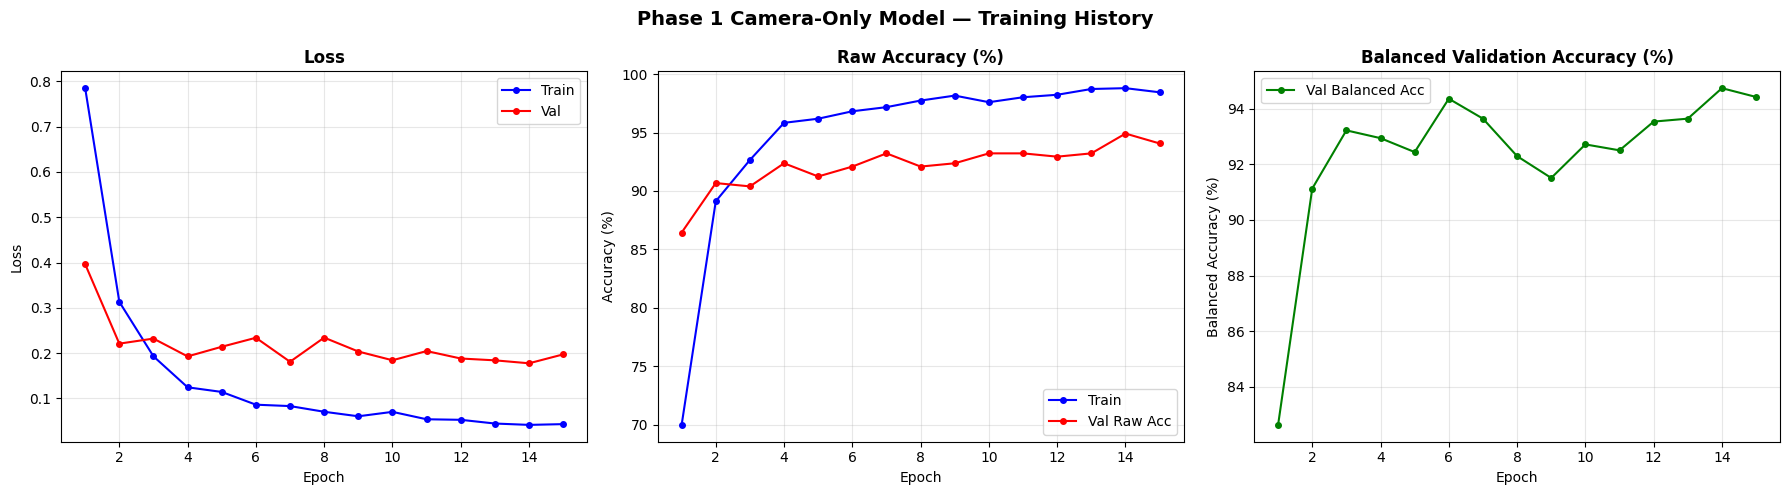

In [7]:
# Plot the standard model training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = np.arange(1, len(history["train_loss"]) + 1)

# Loss
axes[0].plot(epochs, history["train_loss"], "b-o", label="Train", markersize=4)
axes[0].plot(epochs, history["val_loss"], "r-o", label="Val", markersize=4)
axes[0].set_title("Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Raw accuracy
axes[1].plot(epochs, np.array(history["train_acc"]) * 100, "b-o", label="Train", markersize=4)
axes[1].plot(epochs, np.array(history["val_acc"]) * 100, "r-o", label="Val Raw Acc", markersize=4)
axes[1].set_title("Raw Accuracy (%)", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Balanced accuracy
axes[2].plot(epochs, np.array(history["val_bal_acc"]) * 100, "g-o", label="Val Balanced Acc", markersize=4)
axes[2].set_title("Balanced Validation Accuracy (%)", fontweight="bold")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Balanced Accuracy (%)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("Phase 1 Camera-Only Model — Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/phase1_training_history_balanced.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. FGSM Camera Attack

The attack perturbs only the camera image. Because the images are ImageNet-normalized, the adversarial image is clamped using normalized pixel bounds.

In [8]:
# These bounds keep adversarial images valid after ImageNet normalization
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

NORM_LOWER = (0 - IMAGENET_MEAN) / IMAGENET_STD
NORM_UPPER = (1 - IMAGENET_MEAN) / IMAGENET_STD

def clamp_normalized_image(x):
    return torch.max(torch.min(x, NORM_UPPER), NORM_LOWER)


# Generate an FGSM image attack for the camera-only model
def fgsm_attack_camera_only_phase1(model, images, labels, epsilon):
    was_training = model.training
    model.eval()

    images_adv = images.clone().detach().requires_grad_(True)
    labels = labels.clone().detach()

    logits = model(images_adv)
    loss = nn.CrossEntropyLoss()(logits, labels)

    model.zero_grad(set_to_none=True)
    loss.backward()

    adv = images_adv + epsilon * images_adv.grad.sign()
    adv = clamp_normalized_image(adv).detach()

    if was_training:
        model.train()

    return adv


print("Phase 1 FGSM camera-only attack ready.")
print("Correctly clamps ImageNet-normalized images.")

Phase 1 FGSM camera-only attack ready.
Correctly clamps ImageNet-normalized images.


## 9. Train Adversarially Trained Camera-Only Model

This section trains a second camera-only model using mixed batches: 50% clean images and 50% FGSM-attacked images.

In [9]:
# Train the adversarially trained camera-only model
# Match the fusion adversarial-training setup
ADV_TRAIN_EPS = 0.05
ADV_RATIO = 0.5
NUM_EPOCHS_ADV_CAMERA = 15

adv_camera_model = CameraOnlyResNet18(num_classes=NUM_CLASSES).to(device)

adv_optimizer = torch.optim.AdamW([
    {"params": adv_camera_model.image_backbone.parameters(), "lr": 1e-5},
    {"params": adv_camera_model.classifier.parameters(), "lr": 5e-4},
], weight_decay=1e-4)

adv_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    adv_optimizer,
    T_max=NUM_EPOCHS_ADV_CAMERA,
    eta_min=1e-6
)

adv_camera_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_bal_acc": [],
    "per_class_acc": []
}

print(f"Training adversarially trained camera-only model for {NUM_EPOCHS_ADV_CAMERA} epochs...")
print(f"Each batch: {int(ADV_RATIO * 100)}% adversarial camera + {int((1 - ADV_RATIO) * 100)}% clean camera")
print(f"Attack epsilon during training: {ADV_TRAIN_EPS}")
print()
print("Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Bal Acc")
print("-" * 72)

best_adv_camera_bal = 0.0
best_adv_camera_epoch = 0

for epoch in range(1, NUM_EPOCHS_ADV_CAMERA + 1):
    adv_camera_model.train()

    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)

        batch_size = imgs.size(0)
        n_adv = int(batch_size * ADV_RATIO)

        # Start with clean images, then replace part of the batch with attacked images
        mixed_imgs = imgs.clone().detach()

        if n_adv > 0:
            idx = torch.randperm(batch_size, device=device)[:n_adv]

            # Create adversarial images only for the selected batch indices
            adv_imgs = fgsm_attack_camera_only_phase1(
                adv_camera_model,
                imgs[idx],
                lbls[idx],
                epsilon=ADV_TRAIN_EPS
            )

            mixed_imgs[idx] = adv_imgs

        adv_optimizer.zero_grad(set_to_none=True)

        logits = adv_camera_model(mixed_imgs)
        loss = criterion(logits, lbls)

        loss.backward()
        adv_optimizer.step()

        train_loss_sum += loss.item() * batch_size
        train_correct += (logits.argmax(1) == lbls).sum().item()
        train_total += batch_size

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    val_loss, val_acc, val_bal_acc, per_class_acc, val_preds, val_labels = eval_camera(
        adv_camera_model,
        test_loader
    )

    adv_scheduler.step()

    # Save the best adversarially trained checkpoint by balanced accuracy
    if val_bal_acc > best_adv_camera_bal:
        best_adv_camera_bal = val_bal_acc
        best_adv_camera_epoch = epoch
        torch.save(adv_camera_model.state_dict(), "/content/best_adv_camera_only_model.pth")

    adv_camera_history["train_loss"].append(train_loss)
    adv_camera_history["train_acc"].append(train_acc)
    adv_camera_history["val_loss"].append(val_loss)
    adv_camera_history["val_acc"].append(val_acc)
    adv_camera_history["val_bal_acc"].append(val_bal_acc)
    adv_camera_history["per_class_acc"].append(per_class_acc)

    print(
        f"{epoch:>5} | "
        f"{train_loss:>10.4f} | "
        f"{train_acc:>8.2%} | "
        f"{val_loss:>8.4f} | "
        f"{val_acc:>7.2%} | "
        f"{val_bal_acc:>7.2%}"
    )

    if epoch == 1 or epoch % 5 == 0:
        pred_names = [LABEL_NAMES[p] for p in val_preds]
        true_names = [LABEL_NAMES[y] for y in val_labels]

        print("  Val prediction distribution:", dict(Counter(pred_names)))
        print("  Val true distribution      :", dict(Counter(true_names)))

        print("  Per-class val accuracy:")
        for i, name in enumerate(LABEL_NAMES):
            print(f"    {name:>10}: {per_class_acc[i]:.2%}")

print()
print("Adversarially trained camera-only model complete.")
print(f"Best balanced validation accuracy: {best_adv_camera_bal:.2%}")
print(f"Best epoch: {best_adv_camera_epoch}")

adv_camera_model.load_state_dict(torch.load("/content/best_adv_camera_only_model.pth"))
print("Best adversarial camera-only weights loaded.")

Training adversarially trained camera-only model for 15 epochs...
Each batch: 50% adversarial camera + 50% clean camera
Attack epsilon during training: 0.05

Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Bal Acc
------------------------------------------------------------------------
    1 |     1.1962 |   51.27% |   0.7015 |  82.77% |  60.85%
  Val prediction distribution: {'straight': 282, 'turn_left': 22, 'stop': 50}
  Val true distribution      : {'straight': 237, 'turn_left': 41, 'stop': 44, 'turn_right': 32}
  Per-class val accuracy:
      straight: 97.05%
     turn_left: 46.34%
    turn_right: 0.00%
          stop: 100.00%
    2 |     0.8983 |   63.56% |   0.5422 |  83.90% |  61.77%
    3 |     0.7933 |   66.67% |   0.5208 |  86.44% |  76.57%
    4 |     0.6891 |   71.12% |   0.3734 |  85.59% |  79.97%
    5 |     0.6383 |   72.03% |   0.2798 |  90.11% |  85.18%
  Val prediction distribution: {'straight': 240, 'turn_left': 32, 'stop': 47, 'turn_right': 35}
  Val true dis

## 10. Compare Standard vs. Adversarially Trained Camera-Only Models

In [10]:
# Evaluate one model on clean images and attacked images
def evaluate_camera_attack(model, loader, epsilon=0.0):
    model.eval()

    clean_correct = 0
    attack_correct = 0
    total = 0

    clean_class_correct = np.zeros(NUM_CLASSES)
    attack_class_correct = np.zeros(NUM_CLASSES)
    class_total = np.zeros(NUM_CLASSES)

    clean_preds_all = []
    attack_preds_all = []
    labels_all = []

    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)

        if epsilon > 0:
            attack_imgs = fgsm_attack_camera_only_phase1(model, imgs, lbls, epsilon)
        else:
            attack_imgs = imgs.clone().detach()

        with torch.no_grad():
            clean_logits = model(imgs)
            attack_logits = model(attack_imgs)

            clean_preds = clean_logits.argmax(1)
            attack_preds = attack_logits.argmax(1)

        clean_correct += (clean_preds == lbls).sum().item()
        attack_correct += (attack_preds == lbls).sum().item()
        total += len(lbls)

        for c in range(NUM_CLASSES):
            mask = (lbls == c)
            class_total[c] += mask.sum().item()
            clean_class_correct[c] += (clean_preds[mask] == lbls[mask]).sum().item()
            attack_class_correct[c] += (attack_preds[mask] == lbls[mask]).sum().item()

        clean_preds_all.extend(clean_preds.cpu().numpy().tolist())
        attack_preds_all.extend(attack_preds.cpu().numpy().tolist())
        labels_all.extend(lbls.cpu().numpy().tolist())

    clean_acc = clean_correct / total
    attack_acc = attack_correct / total

    clean_pc = np.divide(
        clean_class_correct,
        class_total,
        out=np.zeros_like(clean_class_correct),
        where=class_total > 0
    )

    attack_pc = np.divide(
        attack_class_correct,
        class_total,
        out=np.zeros_like(attack_class_correct),
        where=class_total > 0
    )

    clean_bal = clean_pc.mean()
    attack_bal = attack_pc.mean()

    return {
        "clean_acc": clean_acc,
        "attack_acc": attack_acc,
        "clean_bal": clean_bal,
        "attack_bal": attack_bal,
        "clean_pc": clean_pc,
        "attack_pc": attack_pc,
        "labels": labels_all,
        "clean_preds": clean_preds_all,
        "attack_preds": attack_preds_all
    }


# Epsilon values used for the final robustness comparison
EPSILONS = [0.0, 0.001, 0.003, 0.005, 0.01, 0.03, 0.05, 0.10, 0.20, 0.30]

# Store results for the final 2x2 comparison notebook
phase1_standard_results = {}
phase1_adv_camera_results = {}

print("Running Phase 1 comparison: standard camera-only vs adversarially trained camera-only")
print()
print(
    f"{'Eps':>7} | "
    f"{'Std Clean':>10} | {'Std Attack':>10} | "
    f"{'Adv Clean':>10} | {'Adv Attack':>10} | "
    f"{'Adv Gain':>9}"
)
print("-" * 78)

for eps in EPSILONS:
    std_result = evaluate_camera_attack(camera_model, test_loader, epsilon=eps)
    adv_result = evaluate_camera_attack(adv_camera_model, test_loader, epsilon=eps)

    phase1_standard_results[eps] = std_result
    phase1_adv_camera_results[eps] = adv_result

    gain = adv_result["attack_acc"] - std_result["attack_acc"]

    print(
        f"{eps:>7.3f} | "
        f"{std_result['clean_acc']:>9.2%} | "
        f"{std_result['attack_acc']:>9.2%} | "
        f"{adv_result['clean_acc']:>9.2%} | "
        f"{adv_result['attack_acc']:>9.2%} | "
        f"{gain:>+8.2%}"
    )

Running Phase 1 comparison: standard camera-only vs adversarially trained camera-only

    Eps |  Std Clean | Std Attack |  Adv Clean | Adv Attack |  Adv Gain
------------------------------------------------------------------------------
  0.000 |    94.92% |    94.92% |    94.07% |    94.07% |   -0.85%
  0.001 |    94.92% |    89.27% |    94.07% |    89.27% |   +0.00%
  0.003 |    94.92% |    77.68% |    94.07% |    82.49% |   +4.80%
  0.005 |    94.92% |    60.17% |    94.07% |    77.68% |  +17.51%
  0.010 |    94.92% |    26.55% |    94.07% |    70.62% |  +44.07%
  0.030 |    94.92% |     3.39% |    94.07% |    69.49% |  +66.10%
  0.050 |    94.92% |     3.95% |    94.07% |    77.12% |  +73.16%
  0.100 |    94.92% |    10.45% |    94.07% |    78.53% |  +68.08%
  0.200 |    94.92% |    26.84% |    94.07% |    76.55% |  +49.72%
  0.300 |    94.92% |    47.46% |    94.07% |    74.86% |  +27.40%


## 11. Camera-Only Attack Curve

This plot compares how the standard and adversarially trained camera-only models behave as the attack strength increases.

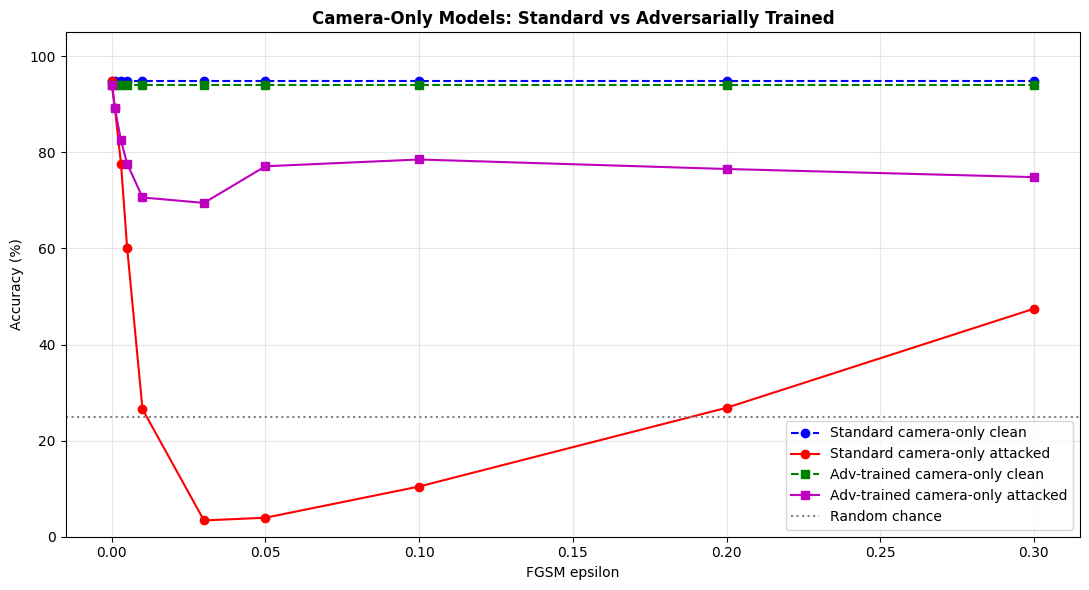

In [11]:
# Plot clean and attacked accuracy for both camera-only models
eps_values = list(phase1_standard_results.keys())

std_clean = [phase1_standard_results[e]["clean_acc"] * 100 for e in eps_values]
std_attack = [phase1_standard_results[e]["attack_acc"] * 100 for e in eps_values]

adv_clean = [phase1_adv_camera_results[e]["clean_acc"] * 100 for e in eps_values]
adv_attack = [phase1_adv_camera_results[e]["attack_acc"] * 100 for e in eps_values]

plt.figure(figsize=(11, 6))

plt.plot(eps_values, std_clean, "b--o", label="Standard camera-only clean")
plt.plot(eps_values, std_attack, "r-o", label="Standard camera-only attacked")

plt.plot(eps_values, adv_clean, "g--s", label="Adv-trained camera-only clean")
plt.plot(eps_values, adv_attack, "m-s", label="Adv-trained camera-only attacked")

plt.axhline(25, linestyle=":", color="gray", label="Random chance")

plt.title("Camera-Only Models: Standard vs Adversarially Trained", fontweight="bold")
plt.xlabel("FGSM epsilon")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("/content/camera_only_standard_vs_adv_attack_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Camera-Only Per-Class Comparison at Epsilon = 0.05

Camera-only per-class comparison at epsilon=0.05
---------------------------------------------------------------------------------------------------------
       Class |     N | Std Clean | Std Attack | Adv Clean | Adv Attack |     Gain
---------------------------------------------------------------------------------------------------------
    straight |   237 |    94.94% |      5.91% |    92.83% |     86.50% |  +80.59%
   turn_left |    41 |    90.24% |      0.00% |    95.12% |     29.27% |  +29.27%
  turn_right |    32 |    93.75% |      0.00% |    93.75% |     43.75% |  +43.75%
        stop |    44 |   100.00% |      0.00% |   100.00% |     95.45% |  +95.45%


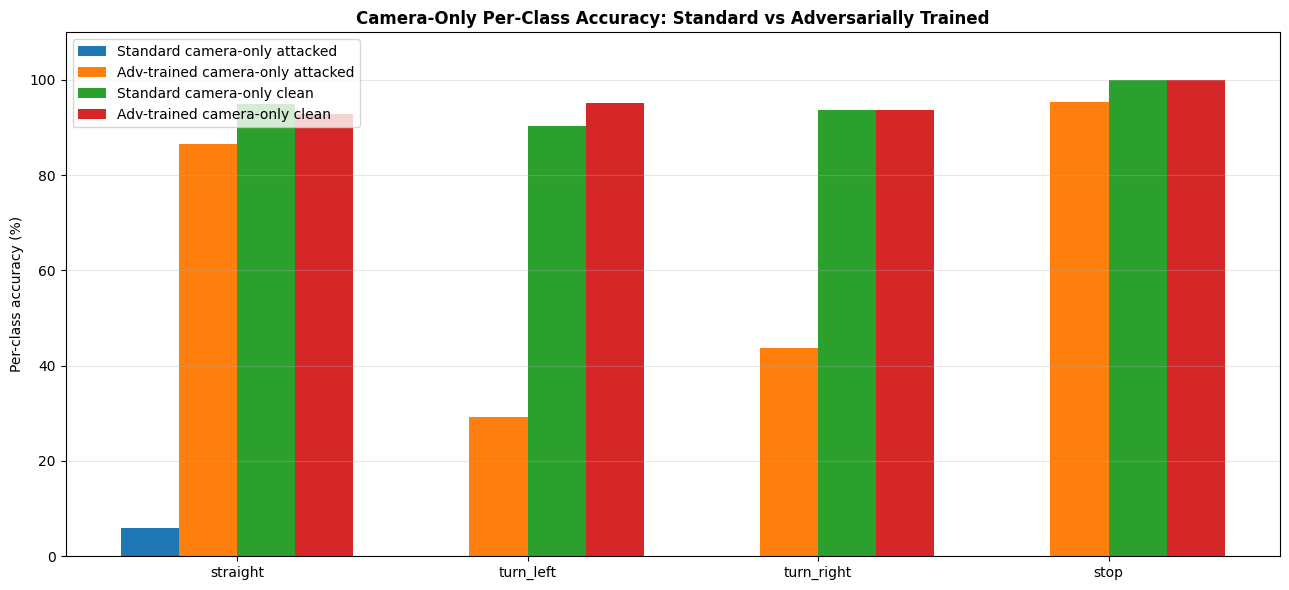

In [12]:
# Compare per-class performance at the main attack strength
EPS = 0.05

std_result = phase1_standard_results[EPS]
adv_result = phase1_adv_camera_results[EPS]

labels_all = np.array(std_result["labels"])
class_totals = np.array([(labels_all == c).sum() for c in range(NUM_CLASSES)])

std_clean_pc = std_result["clean_pc"] * 100
std_attack_pc = std_result["attack_pc"] * 100

adv_clean_pc = adv_result["clean_pc"] * 100
adv_attack_pc = adv_result["attack_pc"] * 100

print(f"Camera-only per-class comparison at epsilon={EPS}")
print("-" * 105)
print(
    f"{'Class':>12} | {'N':>5} | "
    f"{'Std Clean':>9} | {'Std Attack':>10} | "
    f"{'Adv Clean':>9} | {'Adv Attack':>10} | "
    f"{'Gain':>8}"
)
print("-" * 105)

for i, name in enumerate(LABEL_NAMES):
    gain = adv_attack_pc[i] - std_attack_pc[i]

    print(
        f"{name:>12} | "
        f"{int(class_totals[i]):>5} | "
        f"{std_clean_pc[i]:>8.2f}% | "
        f"{std_attack_pc[i]:>9.2f}% | "
        f"{adv_clean_pc[i]:>8.2f}% | "
        f"{adv_attack_pc[i]:>9.2f}% | "
        f"{gain:>+7.2f}%"
    )


x = np.arange(NUM_CLASSES)
w = 0.20

plt.figure(figsize=(13, 6))

plt.bar(x - 1.5*w, std_attack_pc, width=w, label="Standard camera-only attacked")
plt.bar(x - 0.5*w, adv_attack_pc, width=w, label="Adv-trained camera-only attacked")
plt.bar(x + 0.5*w, std_clean_pc, width=w, label="Standard camera-only clean")
plt.bar(x + 1.5*w, adv_clean_pc, width=w, label="Adv-trained camera-only clean")

plt.xticks(x, LABEL_NAMES)
plt.ylabel("Per-class accuracy (%)")
plt.ylim(0, 110)
plt.title("Camera-Only Per-Class Accuracy: Standard vs Adversarially Trained", fontweight="bold")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/content/camera_only_standard_vs_adv_per_class_eps005.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Camera-Only Prediction Distribution at Epsilon = 0.05

This diagnostic output shows how each model's predictions shift under attack.

In [13]:
# Show how predictions shift under attack
EPS = 0.05

std_result = phase1_standard_results[EPS]
adv_result = phase1_adv_camera_results[EPS]

true_names = [LABEL_NAMES[y] for y in std_result["labels"]]

std_clean_names = [LABEL_NAMES[p] for p in std_result["clean_preds"]]
std_attack_names = [LABEL_NAMES[p] for p in std_result["attack_preds"]]

adv_clean_names = [LABEL_NAMES[p] for p in adv_result["clean_preds"]]
adv_attack_names = [LABEL_NAMES[p] for p in adv_result["attack_preds"]]

print(f"Camera-only prediction distributions at epsilon={EPS}")
print("-" * 60)
print("True labels            :", dict(Counter(true_names)))
print("Std clean preds        :", dict(Counter(std_clean_names)))
print("Std attacked preds     :", dict(Counter(std_attack_names)))
print("Adv clean preds        :", dict(Counter(adv_clean_names)))
print("Adv attacked preds     :", dict(Counter(adv_attack_names)))

Camera-only prediction distributions at epsilon=0.05
------------------------------------------------------------
True labels            : {'straight': 237, 'turn_left': 41, 'stop': 44, 'turn_right': 32}
Std clean preds        : {'straight': 231, 'turn_left': 39, 'stop': 44, 'turn_right': 40}
Std attacked preds     : {'turn_right': 152, 'turn_left': 60, 'straight': 128, 'stop': 14}
Adv clean preds        : {'straight': 224, 'turn_left': 45, 'stop': 44, 'turn_right': 41}
Adv attacked preds     : {'straight': 254, 'stop': 46, 'turn_right': 37, 'turn_left': 17}


## 14. Save Results to Google Drive

In [ ]:
# Save final models, figures, and result dictionaries to Google Drive

from google.colab import drive
import os
import shutil
import pickle
import json

drive.mount("/content/drive")

EXPERIMENT_NAME = "CameraOnly_Experiments"

SAVE_DIR = f"/content/drive/MyDrive/AV_Adversarial_Project/{EXPERIMENT_NAME}"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Saving files to: {SAVE_DIR}")
print("-" * 70)


# Save model weights and generated image/video outputs from /content

extensions_to_save = [".pth", ".png", ".jpg", ".jpeg", ".mp4", ".csv"]

saved_files = []

for fname in os.listdir("/content"):
    fpath = os.path.join("/content", fname)

    if os.path.isfile(fpath) and any(fname.endswith(ext) for ext in extensions_to_save):
        dest = os.path.join(SAVE_DIR, fname)
        shutil.copy2(fpath, dest)
        saved_files.append(fname)

print("Saved files from /content:")
if saved_files:
    for f in saved_files:
        print(f"  {f}")
else:
    print("  No .pth/.png/.jpg/.mp4/.csv files found.")


# Save important Python variables if they exist

variables_to_save = {}

possible_variables = [
    # Camera-only notebook
    "history",
    "adv_camera_history",
    "phase1_standard_results",
    "phase1_adv_camera_results",

    # Fusion notebook
    "std_history",
    "adv_history",
    "fusion_standard_results",
    "fusion_adv_results",
    "results_clean",
    "results_conflict",

    # Final comparison notebook
    "camera_standard",
    "camera_adv",
    "fusion_standard",
    "fusion_adv",
    "per_class_attack",
    "summary_rows",
]

for var_name in possible_variables:
    if var_name in globals():
        variables_to_save[var_name] = globals()[var_name]

if variables_to_save:
    pickle_path = os.path.join(SAVE_DIR, "saved_results.pkl")

    with open(pickle_path, "wb") as f:
        pickle.dump(variables_to_save, f)

    print("\nSaved Python result variables:")
    for var_name in variables_to_save.keys():
        print(f"  {var_name}")

    print(f"\nPickle saved to: {pickle_path}")
else:
    print("\nNo matching Python result variables found to save.")


# Save a small human-readable summary file

summary_path = os.path.join(SAVE_DIR, "save_summary.txt")

with open(summary_path, "w") as f:
    f.write(f"Experiment: {EXPERIMENT_NAME}\n")
    f.write(f"Save directory: {SAVE_DIR}\n\n")

    f.write("Saved files:\n")
    for fname in saved_files:
        f.write(f"- {fname}\n")

    f.write("\nSaved variables:\n")
    for var_name in variables_to_save.keys():
        f.write(f"- {var_name}\n")

print(f"\nSummary saved to: {summary_path}")
print("\nDone saving to Google Drive.")

Mounted at /content/drive
Saving files to: /content/drive/MyDrive/AV_Adversarial_Project/CameraOnly_Experiments
----------------------------------------------------------------------
Saved files from /content:
  best_camera_only_model.pth
  camera_only_standard_vs_adv_per_class_eps005.png
  camera_only_standard_vs_adv_attack_curve.png
  phase1_training_history_balanced.png
  best_adv_camera_only_model.pth

Saved Python result variables:
  history
  adv_camera_history
  phase1_standard_results
  phase1_adv_camera_results

Pickle saved to: /content/drive/MyDrive/AV_Adversarial_Project/CameraOnly_Experiments/saved_results.pkl

Summary saved to: /content/drive/MyDrive/AV_Adversarial_Project/CameraOnly_Experiments/save_summary.txt

Done saving to Google Drive.
